[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eirasf/GCED-AA2/blob/main/es/lab5/lab5.ipynb)
# Práctica 5: Optimización de redes neuronales


En este laboratorio trabajaremos con el mismo conjunto de datos que hemos utilizado hasta ahora. Carga todo el conjunto en un solo dataloader (en este laboratorio solo nos ocuparemos de estudiar el ajuste en entrenamiento, no la generalización).

In [4]:
# TODO: Carga los datos
import seaborn as sns
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset
df = sns.load_dataset('titanic')

# 2. Preprocesamiento básico
# Columnas con las que trabajaremos para la predicción de supervivencia (survived)
# Eliminamos redundancias y columnas con demasiados nulos (como deck)
columns_to_keep = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[columns_to_keep].copy()
y = df['survived'].values

# Imputar valores faltantes
X['age'] = X['age'].fillna(X['age'].median())
X['embarked'] = X['embarked'].fillna(X['embarked'].mode()[0])

# Codificar variables categóricas
X = pd.get_dummies(X, columns=['sex', 'embarked'], drop_first=True)

# Convertir todo a float32 para PyTorch
X_values = X.values.astype(np.float32)
y_values = y.astype(np.float32)

# Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_values)

# 3. Crear TensorDataset y DataLoader
tensor_x = torch.tensor(X_scaled, dtype=torch.float32)
tensor_y = torch.tensor(y_values, dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(tensor_x, tensor_y)
# Cargamos todo en un único dataloader
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Datos cargados correctamente. Dimensiones de entrada: {tensor_x.shape}")

Datos cargados correctamente. Dimensiones de entrada: torch.Size([891, 8])


Usaremos la misma arquitectura, función para el aprendizaje, función para evaluación y función de coste que en los laboratorios anteriores. Haz las declaraciones necesarias en la siguiente celda.

Adapta la función `train_model` para que el parámetro `val_loader` pueda ser `None`, en cuyo caso no se calcula la pérdida en validación y se devuelve una lista vacía en la segunda componente de la tupla.

In [5]:
# TODO - Declara las funciones, la arquitectura y la función de pérdida a utilizar
import torch.nn as nn
import torch.optim as optim

# Definición de la arquitectura de la red
class TitanicNet(nn.Module):
    def __init__(self, input_dim):
        super(TitanicNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

# Función de pérdida
criterion = nn.BCELoss()

# Función de evaluación de precisión (accuracy)
def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs)
            predicted = (outputs >= 0.5).float()
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
    return correct / total

# Función para el aprendizaje adaptada para que val_loader pueda ser None
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=100, scheduler=None):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        if val_loader is not None:
            model.eval()
            running_val_loss = 0.0
            with torch.no_grad():
                for inputs, targets in val_loader:
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                    running_val_loss += loss.item() * inputs.size(0)
            epoch_val_loss = running_val_loss / len(val_loader.dataset)
            val_losses.append(epoch_val_loss)

        if scheduler is not None:
            scheduler.step()

    return train_losses, val_losses

Con todo esto listo, haremos una comparativa de los distintos optimizadores que nos ofrece `torch`.

En primer lugar haremos un entrenamiento con un optimizador SGD sin momentum. Instancia el modelo y un optimizador `optim.SGD`. Haz el entrenamiento y muestra la curva de aprendizaje. Prueba distintos valores de *learning rate*. Guarda las curvas de aprendizaje en un diccionario para mostrarlas todas en un mismo gráfico.

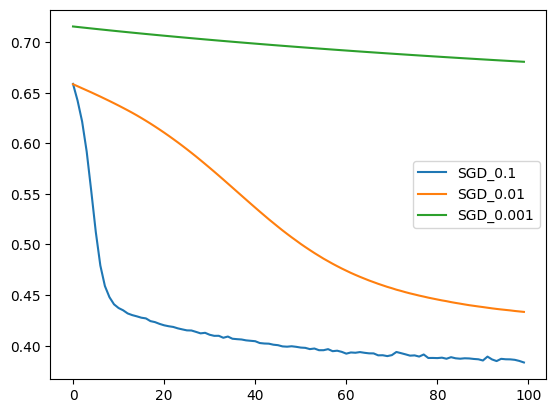

In [6]:
import matplotlib.pyplot as plt

lrs_a_explorar = [0.1, 0.01, 0.001] # TODO - Cambia esta lista para incluir los valores que consideres
histories = {}

# Determinar la dimensión de entrada a partir del dataset
input_dim = tensor_x.shape[1]

for lr in lrs_a_explorar:
    model = TitanicNet(input_dim)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    train_losses, _ = train_model(model, train_loader, None, criterion, optimizer, epochs=100)
    train_accuracy = evaluate_accuracy(model, train_loader)

    # TODO: Guarda el history del entrenamiento
    histories[f'SGD_{lr}'] = {'loss_history': train_losses, 'accuracy_history': train_accuracy}

# Mostramos en gráficas las curvas de aprendizaje que tengamos acumuladas en histories
for k in histories:
    plt.plot(histories[k]['loss_history'], label=k)
plt.legend()
plt.show()

## Comparativas

Repite todo el proceso de entrenamiento realizando cada uno de estos cambios. Haz varias pruebas hasta encontrar valores adecuados. No resetees el kernel ni vuelvas a ejecutar las dos primeras celdas entre las distintas pruebas, o perderás la posibilidad de comparar las curvas de aprendizaje. Recuerda modificar la etiqueta de la curva de cada prueba en la gráfica cuando añadas registros a `histories`.

1. **Tamaño del lote**: Modifica el tamaño de lote al crear el dataloader y compara los resultados
1. **Learning rate variable**: Vuelve sobre la celda en la que se declara el optimizador y utiliza un [scheduler](https://docs.pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) para que el *learning rate* vaya decayendo linealmente con el tiempo. Utiliza los consejos vistos en teoría para elegir los parámetros. Tendrás que modificar tu función de aprendizaje para que acepte el `scheduler` como parámetro y que llame a su método `step` cuando sea necesario. También es útil mostrar por pantalla el *learning rate* en cada epoch.
1. **Uso de momentum**: Vuelve sobre la celda en la que se declara el optimizador y configúralo para que utilice momentum. Consulta los apuntes y la [documentación](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html#sgd) para ayudarte a elegir los hiperparámetros
1. **Otros optimizadores**: Ayúdate de la [documentación](https://docs.pytorch.org/docs/stable/optim.html#algorithms) para probar RMSProp, Adagrad y Adam y compara con los resultados obtenidos hasta ahora.


SGD_0.1                   -> Final Accuracy: 0.8485
SGD_0.01                  -> Final Accuracy: 0.8103
SGD_0.001                 -> Final Accuracy: 0.6296
SGD_0.1_Batch16           -> Final Accuracy: 0.8440
SGD_0.1_Scheduler         -> Final Accuracy: 0.8350
SGD_0.01_Momentum0.9      -> Final Accuracy: 0.8474
Adam_0.001                -> Final Accuracy: 0.8395
RMSprop_0.001             -> Final Accuracy: 0.8451
Adagrad_0.01              -> Final Accuracy: 0.8227


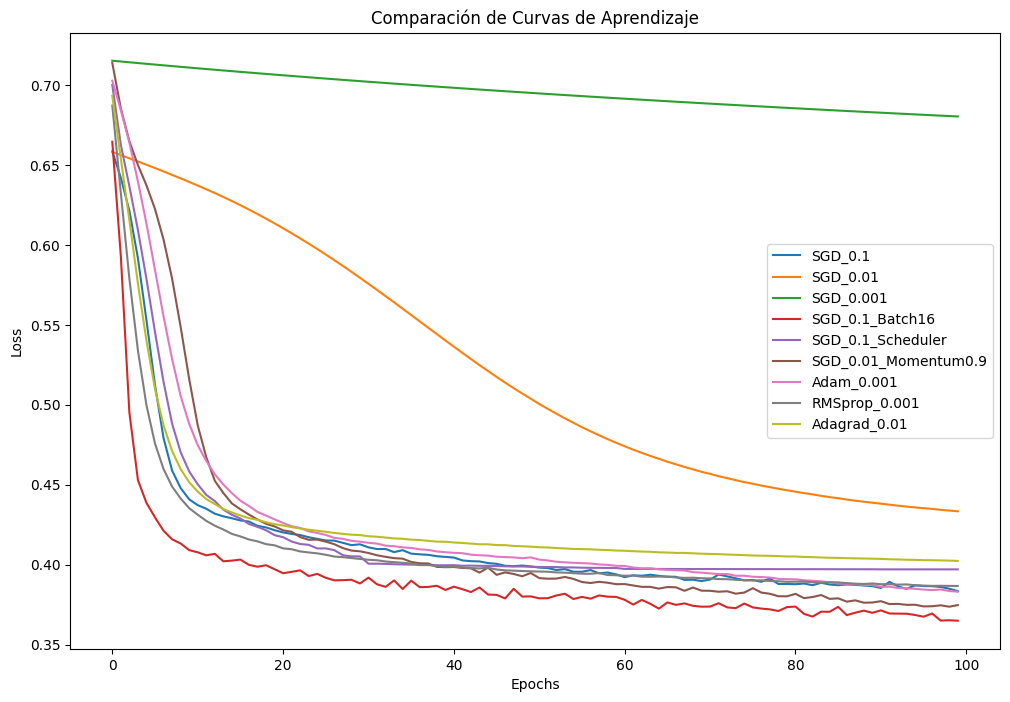

In [7]:
# TODO: Realizar comparativas de tamaño del lote, scheduler, momentum y otros optimizadores

# 1. Comparativa de Tamaño de Lote (Batch Size = 16)
train_loader_bs16 = DataLoader(dataset, batch_size=16, shuffle=True)
model_bs16 = TitanicNet(input_dim)
optimizer_bs16 = optim.SGD(model_bs16.parameters(), lr=0.1)
losses_bs16, _ = train_model(model_bs16, train_loader_bs16, None, criterion, optimizer_bs16, epochs=100)
histories['SGD_0.1_Batch16'] = {'loss_history': losses_bs16, 'accuracy_history': evaluate_accuracy(model_bs16, train_loader_bs16)}

# 2. Comparativa de Learning rate variable (Scheduler)
model_sched = TitanicNet(input_dim)
optimizer_sched = optim.SGD(model_sched.parameters(), lr=0.1)
scheduler = optim.lr_scheduler.StepLR(optimizer_sched, step_size=30, gamma=0.1)
losses_sched, _ = train_model(model_sched, train_loader, None, criterion, optimizer_sched, epochs=100, scheduler=scheduler)
histories['SGD_0.1_Scheduler'] = {'loss_history': losses_sched, 'accuracy_history': evaluate_accuracy(model_sched, train_loader)}

# 3. Comparativa de Uso de Momentum (momentum = 0.9)
model_mom = TitanicNet(input_dim)
optimizer_mom = optim.SGD(model_mom.parameters(), lr=0.01, momentum=0.9)
losses_mom, _ = train_model(model_mom, train_loader, None, criterion, optimizer_mom, epochs=100)
histories['SGD_0.01_Momentum0.9'] = {'loss_history': losses_mom, 'accuracy_history': evaluate_accuracy(model_mom, train_loader)}

# 4. Comparativa de Otros Optimizadores (RMSProp, Adagrad, Adam)
# Adam
model_adam = TitanicNet(input_dim)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam, _ = train_model(model_adam, train_loader, None, criterion, optimizer_adam, epochs=100)
histories['Adam_0.001'] = {'loss_history': losses_adam, 'accuracy_history': evaluate_accuracy(model_adam, train_loader)}

# RMSprop
model_rmsprop = TitanicNet(input_dim)
optimizer_rmsprop = optim.RMSprop(model_rmsprop.parameters(), lr=0.001)
losses_rmsprop, _ = train_model(model_rmsprop, train_loader, None, criterion, optimizer_rmsprop, epochs=100)
histories['RMSprop_0.001'] = {'loss_history': losses_rmsprop, 'accuracy_history': evaluate_accuracy(model_rmsprop, train_loader)}

# Adagrad
model_adagrad = TitanicNet(input_dim)
optimizer_adagrad = optim.Adagrad(model_adagrad.parameters(), lr=0.01)
losses_adagrad, _ = train_model(model_adagrad, train_loader, None, criterion, optimizer_adagrad, epochs=100)
histories['Adagrad_0.01'] = {'loss_history': losses_adagrad, 'accuracy_history': evaluate_accuracy(model_adagrad, train_loader)}

# Mostrar resultados comparativos de precisión
for k in histories:
    print(f"{k:25} -> Final Accuracy: {histories[k]['accuracy_history']:.4f}")

# Graficar comparativa
plt.figure(figsize=(12, 8))
for k in histories:
    plt.plot(histories[k]['loss_history'], label=k)
plt.title('Comparación de Curvas de Aprendizaje')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()